## Grid cell plots

`grid_cells` renders each grid cell as a filled polygon (or pixel) coloured by its data value. Unlike `contourf`, there is no interpolation between cells — the boundary between two adjacent cells is a hard edge, so the native grid structure remains clearly visible.

Key properties:
- For **HEALPix** and **reduced Gaussian** grids, the fast `nnshow` nearest-neighbour pixel backend is used automatically, producing efficient renderings even at high resolution.
- For **regular lat/lon** grids, matplotlib's `pcolormesh` is used, which also preserves sharp cell boundaries.
- The `resample` argument is **not** supported — cell boundaries are always preserved. Use `contourf` with `resample=Bilinear(...)` if you need smooth rendering.

### Example: HEALPix 2 m temperature

We load a HEALPix GRIB file and plot the individual pixel cells.

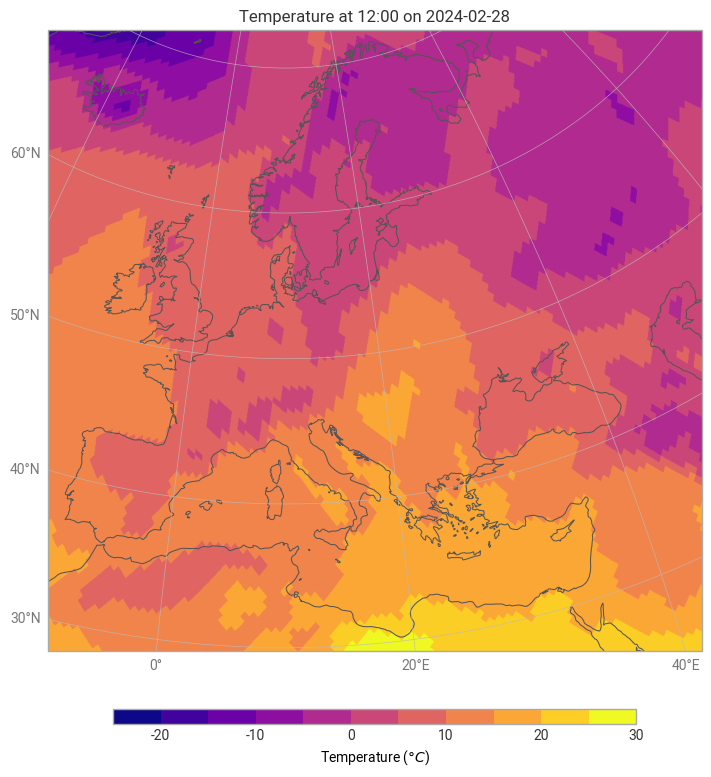

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "healpix-h128-nested-2t.grib")

chart = ekp.Map(domain="Europe")

chart.grid_cells(data, units="celsius")

chart.coastlines()
chart.gridlines()
chart.legend()
chart.title()

chart.show()

### Applying a style

Pass a `Style` object to control the colour map, levels and units.

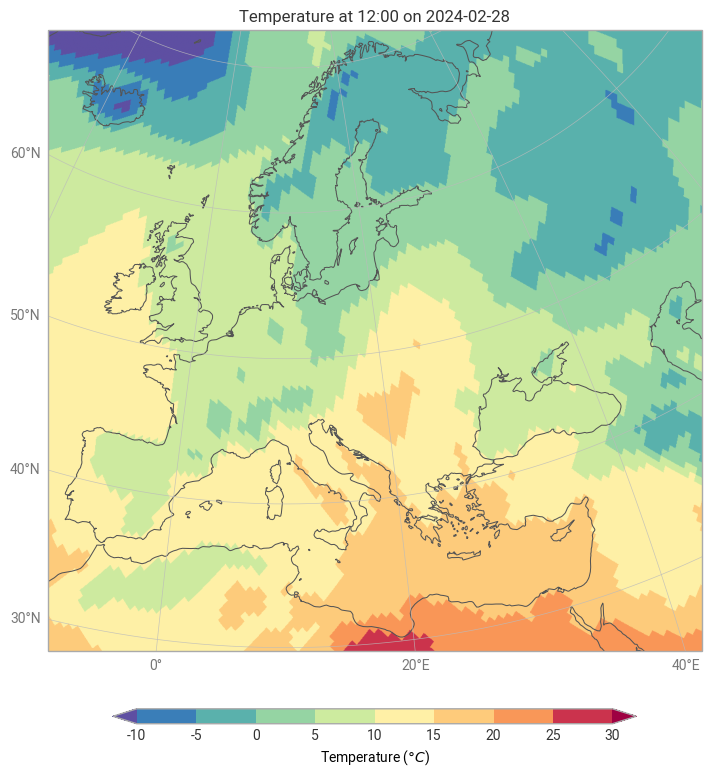

In [2]:
style = ekp.styles.Style(
    colors="Spectral_r",
    levels=range(-10, 35, 5),
    units="celsius",
    extend="both",
)

chart = ekp.Map(domain="Europe")

chart.grid_cells(data, style=style)

chart.coastlines()
chart.gridlines()
chart.legend()
chart.title()

chart.show()

### Regular lat/lon data

`grid_cells` works equally well on regular lat/lon GRIB or netCDF data. For regular grids, `pcolormesh` is used under the hood.

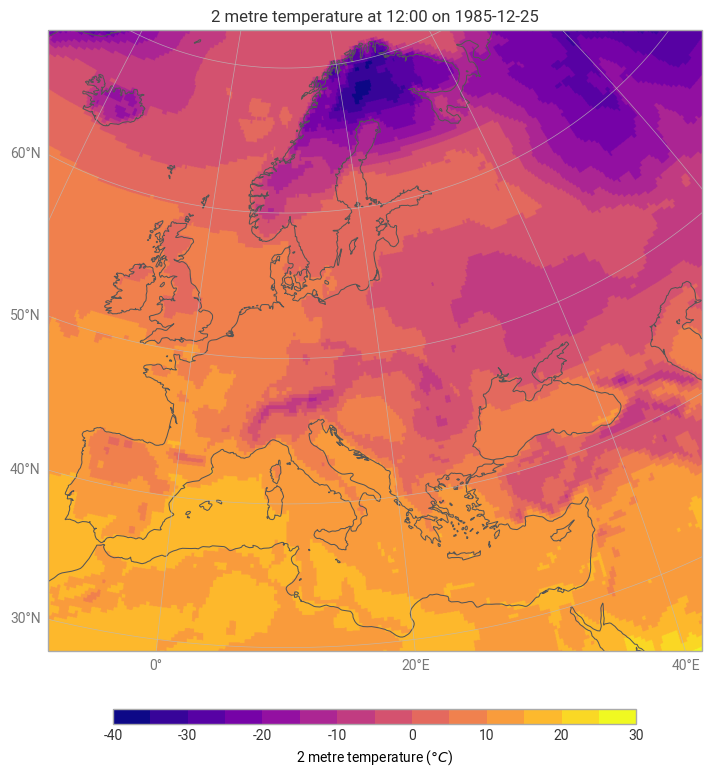

In [3]:
ll_data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature = ll_data.sel({"parameter.variable": "2t"})

chart = ekp.Map(domain="Europe")

chart.grid_cells(temperature, units="celsius")

chart.coastlines()
chart.gridlines()
chart.legend()
chart.title()

chart.show()

### Comparing grid_cells with contourf

The difference between `grid_cells` and `contourf` is most apparent when zooming in to a region where individual cells are visible. `contourf` smooths across cell boundaries; `grid_cells` does not.

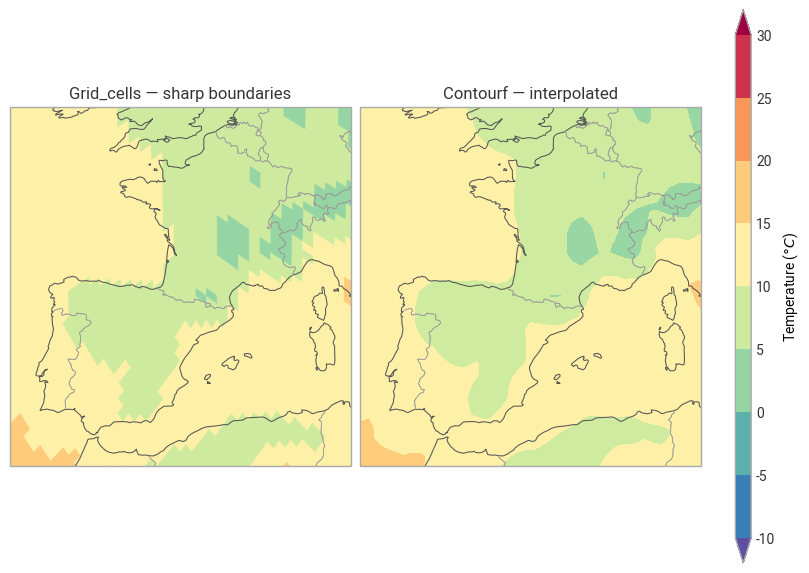

In [4]:
figure = ekp.Figure(rows=1, columns=2, domain=["France", "Spain"])

ax = figure.add_map()
ax.grid_cells(data, style=style)
ax.title("grid_cells — sharp boundaries")

ax = figure.add_map()
ax.contourf(data, style=style)
ax.title("contourf — interpolated")

figure.coastlines()
figure.borders()
figure.legend(location="right")

figure.show()

### Overlaying grid cells with contour lines

A useful combination is `grid_cells` for the shaded background and `contour` for isolines on top.

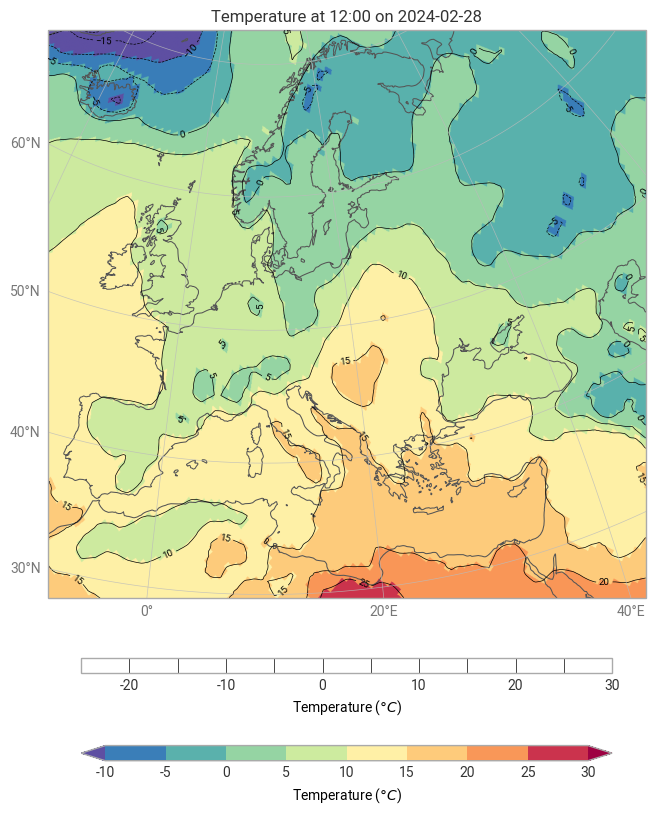

In [5]:
chart = ekp.Map(domain="Europe")

chart.grid_cells(data, style=style)
chart.contour(data, units="celsius", colors="black", linewidths=0.5)

chart.coastlines()
chart.gridlines()
chart.legend()
chart.title()

chart.show()